# Bet Simulator
In questo notebook è contenuto il bet simulator del progetto. L'obiettivo è comprendere, utilizzando i vari modelli e impostando una metodologia di scommesse, quanto sarebbe il guadagno ottenuto da ciascun modello (compresa la baseline casuale).

## Metodologia di scommessa
L'approccio che utilizziamo è semplice, scommettere 10 euro su ogni partita, sulla classe consigliata dal nostro modello

## Importazione dei dataset e merge
Per prima cosa facciamo la merge tra i due dataset (scommesse e partite) importati, di modo da avere tutti i dati necessari per verificare il possibile guadagno totale.  

In [17]:
import pandas as pd
import difflib
import numpy as np

class OddsDataset:

    __odds_dataset: pd.DataFrame
    __match_dataset: pd.DataFrame
    __merged_dataset: pd.DataFrame

    def __merge_dataset(self) -> None:

        # Normalizzazione delle date
        self.__match_dataset['Match_Date_Temp'] = pd.to_datetime(
            self.__match_dataset['Date'], 
            errors='coerce' 
        ).dt.date

        self.__odds_dataset['Odds_Date_Temp'] = pd.to_datetime(
            self.__odds_dataset['matchDate'], 
            format="%d-%m-%y %H:%M", 
            errors='coerce' 
        ).dt.date

        # Risoluzione dei nomi delle squadre
        self.__match_dataset = self.__match_dataset.dropna(subset=['Match_Date_Temp'])
        self.__odds_dataset = self.__odds_dataset.dropna(subset=['Odds_Date_Temp'])
        match_teams = pd.concat([self.__match_dataset['HomeTeam'], self.__match_dataset['AwayTeam']]).unique()
        odds_teams = pd.concat([self.__odds_dataset['homeTeam'], self.__odds_dataset['awayTeam']]).unique()

        team_mapping = {}
        for team in odds_teams:
            matches = difflib.get_close_matches(team, match_teams, n=1, cutoff=0.5)
            team_mapping[team] = matches[0] if matches else team

        self.__odds_dataset['homeTeam_Norm'] = self.__odds_dataset['homeTeam'].map(team_mapping)
        self.__odds_dataset['awayTeam_Norm'] = self.__odds_dataset['awayTeam'].map(team_mapping)

        # Affiancamento dei due dataset
        self.__merged_dataset = pd.merge(
            left=self.__match_dataset,
            right=self.__odds_dataset,
            left_on=['Match_Date_Temp', 'HomeTeam', 'AwayTeam'],
            right_on=['Odds_Date_Temp', 'homeTeam_Norm', 'awayTeam_Norm'],
            how='inner' 
        )

        # Pulizia delle colonne temporanee create per il merge
        col_rimuovere_match = ['Match_Date_Temp']
        col_rimuovere_odds = ['Odds_Date_Temp', 'homeTeam_Norm', 'awayTeam_Norm']
        
        # Le puliamo sia dai dataset originali che dal dataset finale
        self.__match_dataset.drop(columns=col_rimuovere_match, inplace=True, errors='ignore')
        self.__odds_dataset.drop(columns=col_rimuovere_odds, inplace=True, errors='ignore')
        self.__merged_dataset.drop(columns=col_rimuovere_match + col_rimuovere_odds, inplace=True, errors='ignore')

    def __dataset_feature(self):
        
        self.__merged_dataset["WinStreak"] = self.__merged_dataset["Home_WinStreak"] - self.__merged_dataset["Away_WinStreak"]
        self.__merged_dataset["Z_Goals_Season"] = self.__merged_dataset["Z_Home_Goals_Season"] - self.__merged_dataset["Z_Away_Goals_Season"]
        self.__merged_dataset["Z_Wins_Season"] = self.__merged_dataset["Z_Home_Wins_Season"] - self.__merged_dataset["Z_Away_Wins_Season"]
        self.__merged_dataset["GoalOnShotRatio"] = self.__merged_dataset["GoalOnShotRatioHome"] - self.__merged_dataset["GoalOnShotRatioAway"]
        self.__merged_dataset["PointToMatchRatio"] = self.__merged_dataset["PointToMatchRatioHome"] - self.__merged_dataset["PointToMatchRatioAway"]
        self.__merged_dataset['Abs_Points_Difference'] = (self.__merged_dataset['Home_Current_Points'] - self.__merged_dataset['Away_Current_Points']).abs()
        self.__merged_dataset["Elo"] = self.__merged_dataset["HomeElo"] - self.__merged_dataset["AwayElo"]
        self.__merged_dataset["Abs_Value_Difference"] = (self.__merged_dataset["HomeValue"] - self.__merged_dataset["AwayValue"]).abs()
        self.__merged_dataset["Value"] = self.__merged_dataset["HomeValue"] - self.__merged_dataset["AwayValue"]
        self.__merged_dataset['Is_Points_Balanced'] = (self.__merged_dataset['Abs_Points_Difference'] <= 3).astype(int)

        # Elimino le feature inutilizzate
        self.__merged_dataset = self.__merged_dataset.drop(columns=["Home_WinStreak", "Away_WinStreak", "Z_Home_Goals_Season", "Z_Away_Goals_Season", "Z_Home_Wins_Season", "Z_Away_Wins_Season", "GoalOnShotRatioHome", "GoalOnShotRatioAway", "PointToMatchRatioHome", "PointToMatchRatioAway", "HomeElo", "AwayElo", "HomeValue", "AwayValue"])

    def __init__(
            self,
            odds_dataframe_path: str,
            match_dataframe_path
    ) -> None:

        # Importazione e rimozione delle rows vuote 
        self.__odds_dataset = pd.read_csv(odds_dataframe_path)
        self.__match_dataset = pd.read_csv(match_dataframe_path)
        self.__odds_dataset = self.__odds_dataset.dropna()

        # Merge dei due dataset
        self.__merge_dataset()
        self.__dataset_feature()

    @property
    def merge_dataset(self) -> pd.DataFrame:
        return self.__merged_dataset
    

In [18]:
# Merge del dataset ed esportazione del dataset nuovo
gestore_quote = OddsDataset("static/odds/odds.csv", "static/da-result/result.csv")
merged_dataset = gestore_quote.merge_dataset


In [19]:
class Backtest:

    __merge_dataset: pd.DataFrame


    def __init__(self, dataset: pd.DataFrame, season: int | None = None):
        
        # Verifica della stagione
        if season:
            self.__merge_dataset = dataset[dataset["Season_x"] == f"{season}-{season+1}"]
        else:
            self.__merge_dataset = dataset
    
    def random(self):
        """
        Baseline che utilizza una funzione casuale per scommettere su una determinata classe
        """
        
        import matplotlib.pyplot as plt
        
        # Gestione iniziale variabili
        selected_df = self.__merge_dataset.copy()
        rng = np.random.default_rng()
        n = len(selected_df)
        n_simulations = 1000

        if n == 0:
            return np.array([])

        result_map = {0: 'H', 1: 'D', 2: 'A'}
        odds_matrix = selected_df[['H', 'D', 'A']].to_numpy(dtype=float)
        results = selected_df['FTR'].to_numpy()
        cash_in = 10 * n

        predictions = rng.integers(0, 3, size=(n_simulations, n))
        pred_labels = np.vectorize(result_map.get)(predictions)
        correct = pred_labels == results[np.newaxis, :]

        row_idx = np.arange(n)
        selected_odds = odds_matrix[row_idx, predictions]

        earn_per_sim = np.sum(np.where(correct, 10 * selected_odds, 0.0), axis=1)
        profit = earn_per_sim - cash_in

        mean_profit = profit.mean()
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.hist(profit, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
        ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Break-even')
        ax.axvline(mean_profit, color='red', linestyle='-', linewidth=1.5, label=f'Media: {mean_profit:.2f}')
        ax.set_title('Distribuzione del guadagno')
        ax.set_xlabel('Guadagno netto')
        ax.set_ylabel('Frequenza')
        ax.legend()
        plt.tight_layout()
        plt.show()

        return profit, mean_profit

    def scikit_model(
        self,
        model_path: str,
        baseline_features: list[str],
        draw_threshold: float = 0.33,
        scaler: str | None = None
    ):
        """
        Metodo che permette di ottenere il guadagno di scommesse a partire da un modello di scikit-learn. Abbiamo una variabile
        draw_treshold che rappresenta la soglia dei pareggi
        """
        import joblib

        loaded = joblib.load(model_path)
        stake = 10

        if isinstance(loaded, (tuple, list)):
            model, scaler = loaded[0], loaded[1]
        
        elif isinstance(loaded, dict):
            model, scaler = loaded.get('model'), loaded.get('scaler')
            baseline_features = loaded.get('features', baseline_features)
        
        else:
            model = loaded

        selected_df = self.__merge_dataset
        n = len(selected_df)
        
        if n == 0:
            return 0.0

        result_map = {0: 'H', 1: 'D', 2: 'A'}
        X = selected_df[baseline_features]
        X_scaled = scaler.transform(X) if scaler is not None else X

        probs = model.predict_proba(X_scaled)
        predictions = np.where(
            probs[:, 1] >= draw_threshold,
            1,
            np.where(probs[:, 0] > probs[:, 2], 0, 2)
        )
        pred_labels = np.vectorize(result_map.get)(predictions)

        odds_matrix = selected_df[['H', 'D', 'A']].to_numpy(dtype=float)
        results = selected_df['FTR'].to_numpy()

        correct = pred_labels == results
        selected_odds = odds_matrix[np.arange(n), predictions]

        earn = np.sum(np.where(correct, stake * selected_odds, 0.0))
        cash_in = stake * n
        return float(earn - cash_in)



## Utilizzo dei modelli
Applichiamo adesso le strategie precedentemente definite ai modelli che abbiamo esportato dal notebook [results-prediction-model.ipynb](notebook/results-prediction-model.ipynb). 

In [20]:
bt = Backtest(merged_dataset)

### Random Baseline
Tramite questo metodo visualizziamo il profitto che si genera se si scommette casualmente sulle partite (a noi interessa la media e la distribuzione, che possiamo osservare essere circa una Gaussiana).

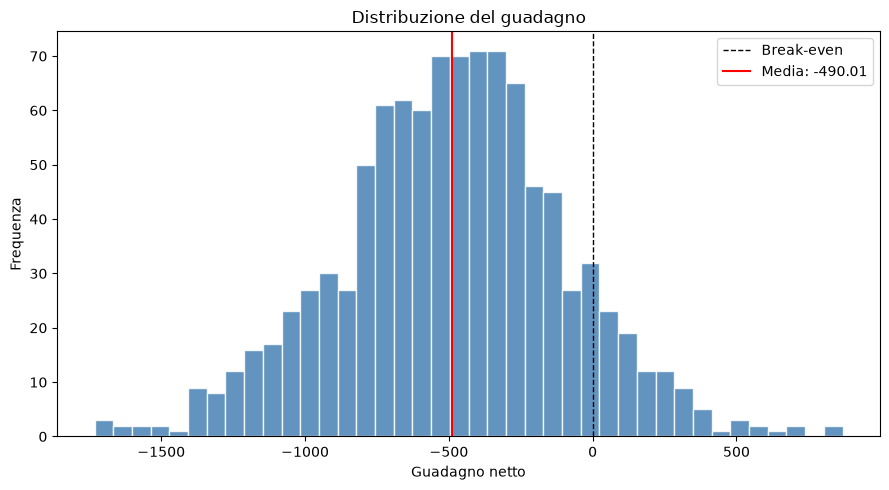

-490.0145


In [21]:
_, mean_profit_baseline = bt.random()
print(mean_profit_baseline)

### Regressione logistica
In questo caso scommetto usando la regressione logistica. Consideriamo che la soglia dei pareggi è impostata al 27%, come consigliato dal nostro modello. In questo caso notiamo un guadagno (per le stagioni del test set) di 329 euro.

In [22]:
profit_reg = bt.scikit_model("static/models/linear_model.joblib", ["WinStreak", "GoalOnShotRatio", "Elo", "HomeAdvantage", "Z_Goals_Season", "Abs_Points_Difference"], 0.27)
print(profit_reg)

329.1999999999998


### Random Forest
In questo caso scommetto con il modello di random forest: otteniamo un guadagno di circa 711 euro. In questo caso la soglia è impostata al 29%.

In [24]:
profit_random_forest = bt.scikit_model("static/models/random_forest_model.joblib", ["Value", "Z_Wins_Season", "Abs_Value_Difference", "HomeAdvantage"], 0.29)
print(profit_random_forest)

780.8999999999996


### XgBoost
L'ultumo modello, ovvero l'XgBoost, ottiene un guadangno di 414 euro per la stagione del 2025.

In [ ]:
profit_xgboost = bt.scikit_model("static/models/random_xgboost_model.joblib", ["Value", "Z_Wins_Season", "Abs_Value_Difference"], 0.29)
print(profit_xgboost)

414.40000000000055


## Conclusioni
Concludiamo con il grafico rappresentato qua sotto, che rappresenta il profitto (normalizzato rispetto alla spesa, ovvero 7600 euro) che ogni modello ha realizzato.

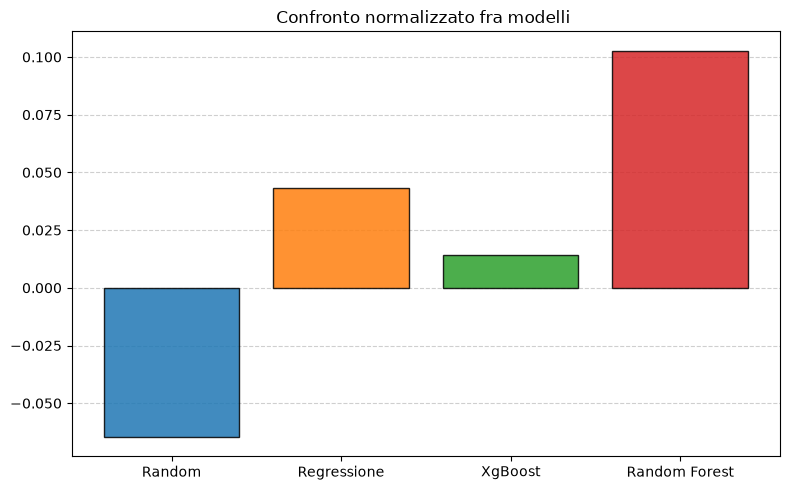

In [25]:
import matplotlib.pyplot as plt

# Modelli e valori
modelli = ['Random', 'Regressione', 'XgBoost', 'Random Forest']
valori = np.array([mean_profit_baseline, profit_reg, profit_xgboost, profit_random_forest]) / 7600

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(modelli, valori, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black', alpha=0.85)


ax.set_title("Confronto normalizzato fra modelli ")

ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True) 

plt.tight_layout()
plt.savefig("norm.png")
plt.show()